In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix

In [155]:
df = pd.read_csv("health_lifestyle_dataset.csv")

print("\n First 5 Rows:\n", df.head())
print("\n Dataset Shape:", df.shape)
print("\n Dataset Info:\n")
print(df.info())



 First 5 Rows:
    id  age  gender   bmi  daily_steps  sleep_hours  water_intake_l  \
0   1   56    Male  20.5         4198          3.9             3.4   
1   2   69  Female  33.3        14359          9.0             4.7   
2   3   46    Male  31.6         1817          6.6             4.2   
3   4   32  Female  38.2        15772          3.6             2.0   
4   5   60  Female  33.6         6037          3.8             4.0   

   calories_consumed  smoker  alcohol  resting_hr  systolic_bp  diastolic_bp  \
0               1602       0        0          97          161           111   
1               2346       0        1          68          116            65   
2               1643       0        1          90          123            99   
3               2460       0        0          71          165            95   
4               3756       0        1          98          139            61   

   cholesterol  family_history  disease_risk  
0          240               0    

# Statistical Summary

In [158]:
print("\n Statistical Summary:\n", df.describe())


 Statistical Summary:
                   id            age            bmi   daily_steps  \
count  100000.000000  100000.000000  100000.000000  100000.00000   
mean    50000.500000      48.525990      29.024790   10479.87029   
std     28867.657797      17.886768       6.352666    5483.63236   
min         1.000000      18.000000      18.000000    1000.00000   
25%     25000.750000      33.000000      23.500000    5729.00000   
50%     50000.500000      48.000000      29.000000   10468.00000   
75%     75000.250000      64.000000      34.500000   15229.00000   
max    100000.000000      79.000000      40.000000   19999.00000   

         sleep_hours  water_intake_l  calories_consumed         smoker  \
count  100000.000000   100000.000000      100000.000000  100000.000000   
mean        6.491784        2.751496        2603.341200       0.200940   
std         2.021922        1.297338         807.288563       0.400705   
min         3.000000        0.500000        1200.000000       0.000

# Missing Values

In [159]:
print("\n Missing Values:\n", df.isnull().sum())


 Missing Values:
 id                   0
age                  0
gender               0
bmi                  0
daily_steps          0
sleep_hours          0
water_intake_l       0
calories_consumed    0
smoker               0
alcohol              0
resting_hr           0
systolic_bp          0
diastolic_bp         0
cholesterol          0
family_history       0
disease_risk         0
dtype: int64


# Duplicate Check

In [160]:
print("\n Duplicate Rows:", df.duplicated().sum())


 Duplicate Rows: 0


# Histograms

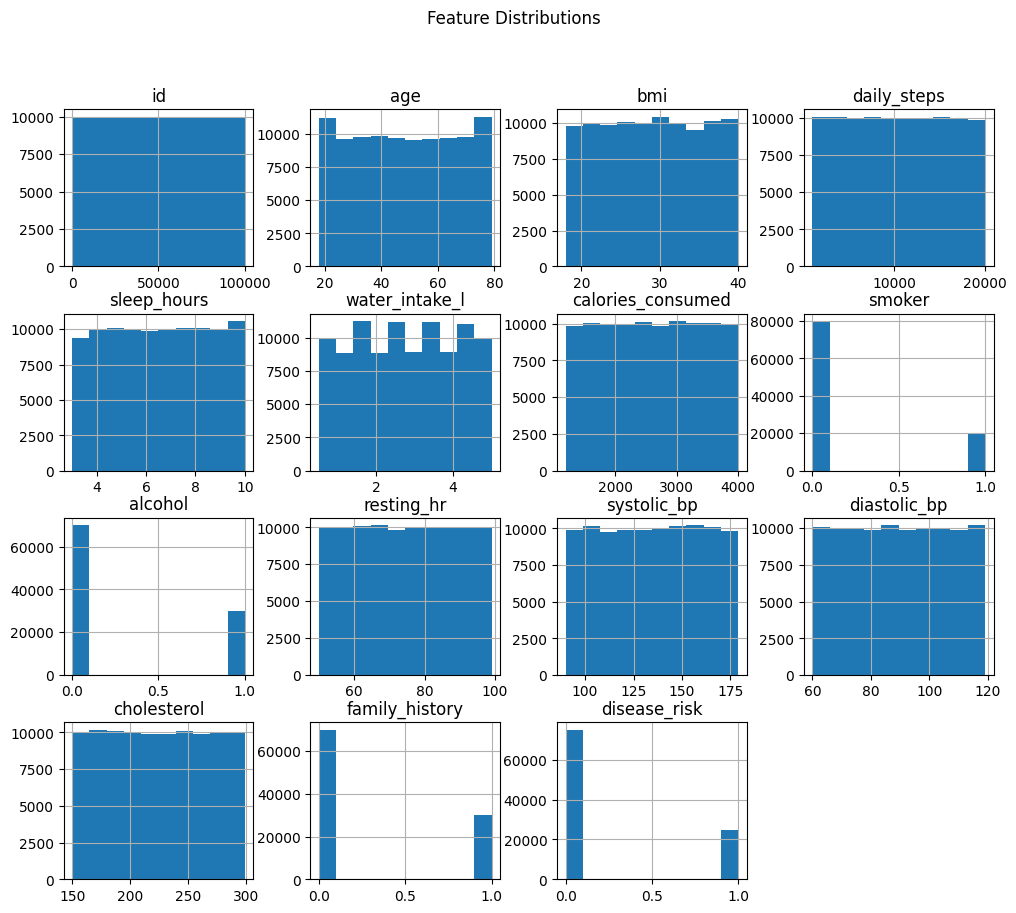

In [161]:
df.hist(figsize=(12, 10))
plt.suptitle("Feature Distributions")
plt.show()

# Correlation Heatmap (FIXED - numeric only)

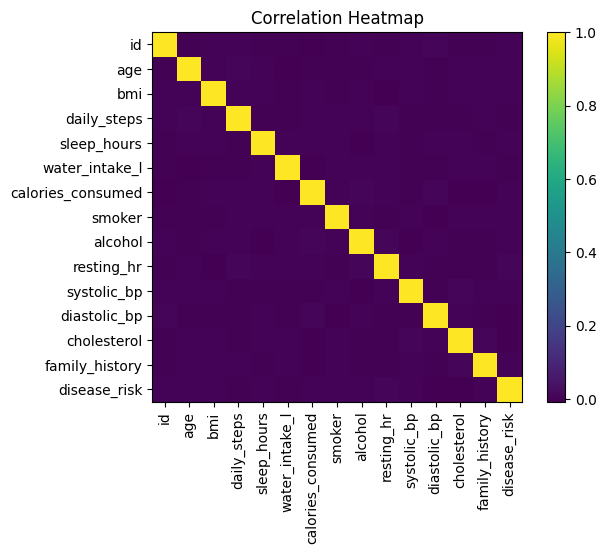

In [162]:
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Heatmap")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()

In [163]:
df = df.drop_duplicates()

# Handle missing values
df = df.dropna()

# Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

print("\n After preprocessing:\n", df.head())


 After preprocessing:
    id  age  gender   bmi  daily_steps  sleep_hours  water_intake_l  \
0   1   56       1  20.5         4198          3.9             3.4   
1   2   69       0  33.3        14359          9.0             4.7   
2   3   46       1  31.6         1817          6.6             4.2   
3   4   32       0  38.2        15772          3.6             2.0   
4   5   60       0  33.6         6037          3.8             4.0   

   calories_consumed  smoker  alcohol  resting_hr  systolic_bp  diastolic_bp  \
0               1602       0        0          97          161           111   
1               2346       0        1          68          116            65   
2               1643       0        1          90          123            99   
3               2460       0        0          71          165            95   
4               3756       0        1          98          139            61   

   cholesterol  family_history  disease_risk  
0          240             

C:\Users\ramya\AppData\Local\Temp\ipykernel_22932\4248072934.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [164]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [165]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

 MODEL 1 - LOGISTIC REGRESSION

In [167]:
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)
y_prob_lr = model_lr.predict_proba(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
loss_lr = log_loss(y_test, y_prob_lr)

print("\n Logistic Regression")
print("Accuracy:", acc_lr)
print("Log Loss:", loss_lr)


 Logistic Regression
Accuracy: 0.7521
Log Loss: 0.5602775073861586


MODEL 2 - RANDOM FOREST

In [168]:
model_rf = RandomForestClassifier()
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)
y_prob_rf = model_rf.predict_proba(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
loss_rf = log_loss(y_test, y_prob_rf)

print("\n Random Forest")
print("Accuracy:", acc_rf)
print("Log Loss:", loss_rf)



 Random Forest
Accuracy: 0.75205
Log Loss: 0.5697663931531529


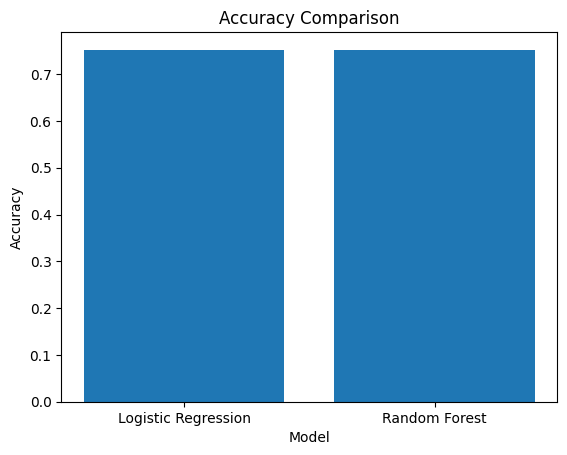

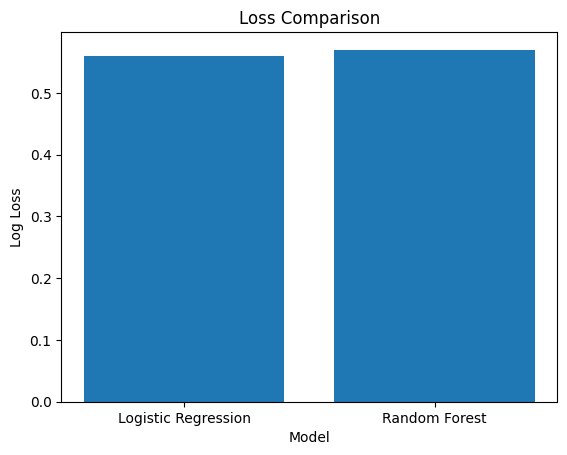

In [169]:
# Accuracy comparison
plt.figure()
plt.bar(['Logistic Regression', 'Random Forest'], [acc_lr, acc_rf])
plt.title("Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

# Loss comparison
plt.figure()
plt.bar(['Logistic Regression', 'Random Forest'], [loss_lr, loss_rf])
plt.title("Loss Comparison")
plt.xlabel("Model")
plt.ylabel("Log Loss")
plt.show()

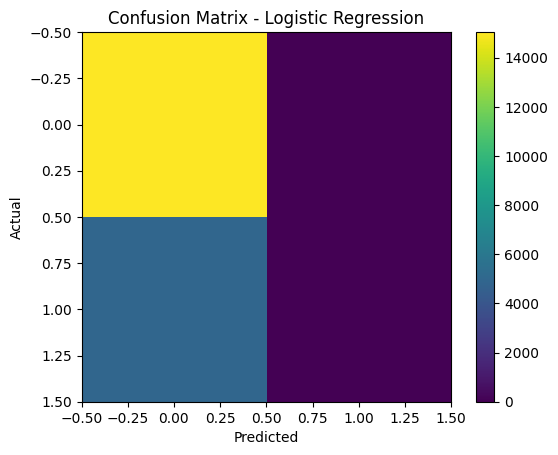

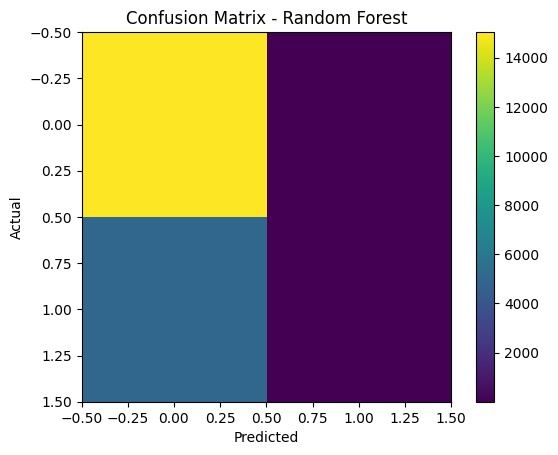

In [170]:
# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure()
plt.imshow(cm_lr)
plt.title("Confusion Matrix - Logistic Regression")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure()
plt.imshow(cm_rf)
plt.title("Confusion Matrix - Random Forest")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


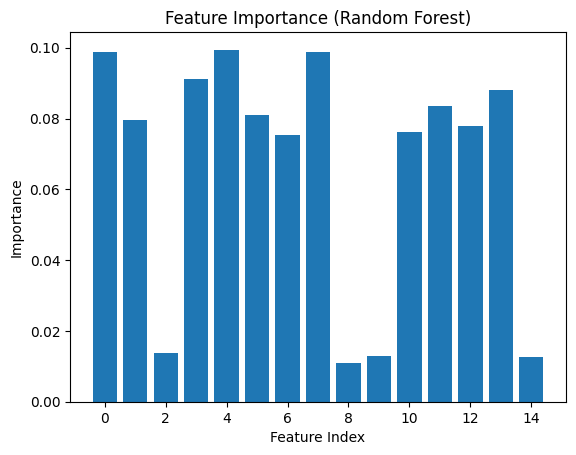

In [171]:
importance = model_rf.feature_importances_

plt.figure()
plt.bar(range(len(importance)), importance)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()

In [172]:
print("\n================ FINAL RESULTS ================")
print(f"Logistic Regression -> Accuracy: {acc_lr}, Loss: {loss_lr}")
print(f"Random Forest       -> Accuracy: {acc_rf}, Loss: {loss_rf}")

if acc_lr > acc_rf:
    print("\n Logistic Regression performs better.")
else:
    print("\n Random Forest performs better.")


================ FINAL RESULTS ================
Logistic Regression -> Accuracy: 0.7521, Loss: 0.5602775073861586
Random Forest       -> Accuracy: 0.75205, Loss: 0.5697663931531529

 Logistic Regression performs better.


In [173]:
print("\n INSIGHTS:")
print(" Dataset cleaned by removing missing values and duplicates.")
print(" Correlation analysis performed only on numeric features.")
print(" Logistic Regression works well for simpler relationships.")
print(" Random Forest captures complex patterns.")
print(" Similar accuracy indicates moderate dataset complexity.")
print(" Feature importance shows which variables influence predictions.")


 INSIGHTS:
 Dataset cleaned by removing missing values and duplicates.
 Correlation analysis performed only on numeric features.
 Logistic Regression works well for simpler relationships.
 Random Forest captures complex patterns.
 Similar accuracy indicates moderate dataset complexity.
 Feature importance shows which variables influence predictions.


In [174]:
!pip install xgboost

In [175]:
from xgboost import XGBClassifier

In [176]:
model_xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss'
)

model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)
y_prob_xgb = model_xgb.predict_proba(X_test)

# Metrics
acc_xgb = accuracy_score(y_test, y_pred_xgb)
loss_xgb = log_loss(y_test, y_prob_xgb)

print("\n XGBoost")
print("Accuracy:", acc_xgb)
print("Log Loss:", loss_xgb)

C:\Users\ramya\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:04:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 XGBoost
Accuracy: 0.7472
Log Loss: 0.5802380324925575


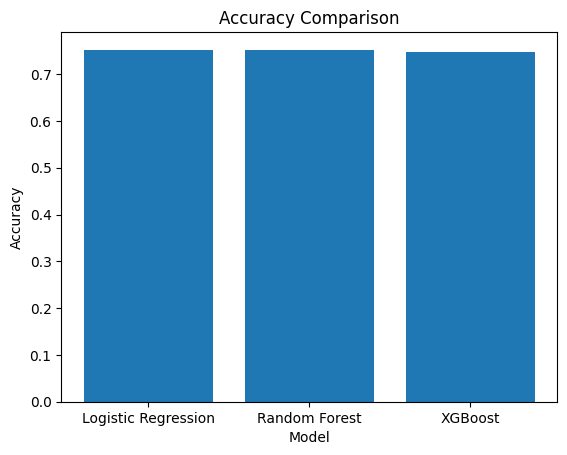

In [177]:
plt.figure()
plt.bar(
    ['Logistic Regression', 'Random Forest', 'XGBoost'],
    [acc_lr, acc_rf, acc_xgb]
)
plt.title("Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

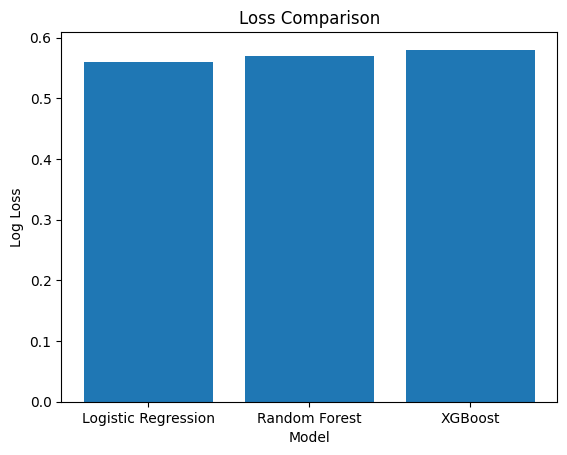

In [178]:
plt.figure()
plt.bar(
    ['Logistic Regression', 'Random Forest', 'XGBoost'],
    [loss_lr, loss_rf, loss_xgb]
)
plt.title("Loss Comparison")
plt.xlabel("Model")
plt.ylabel("Log Loss")
plt.show()

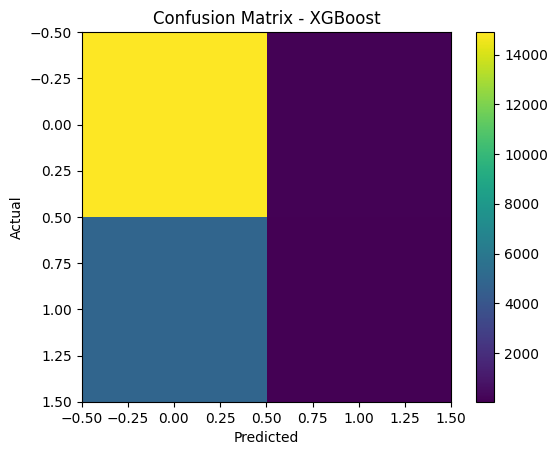

In [179]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure()
plt.imshow(cm_xgb)
plt.title("Confusion Matrix - XGBoost")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [180]:
print("\n================ FINAL RESULTS ================")
print(f"Logistic Regression -> Accuracy: {acc_lr}, Loss: {loss_lr}")
print(f"Random Forest       -> Accuracy: {acc_rf}, Loss: {loss_rf}")
print(f"XGBoost             -> Accuracy: {acc_xgb}, Loss: {loss_xgb}")

best_model = max(
    [('LR', acc_lr), ('RF', acc_rf), ('XGB', acc_xgb)],
    key=lambda x: x[1]
)

print(f"\n Best Model: {best_model[0]}")


================ FINAL RESULTS ================
Logistic Regression -> Accuracy: 0.7521, Loss: 0.5602775073861586
Random Forest       -> Accuracy: 0.75205, Loss: 0.5697663931531529
XGBoost             -> Accuracy: 0.7472, Loss: 0.5802380324925575

 Best Model: LR
